# Directions:

This is a demo for fusion of PaviaU dataset with BASFE

Please simply run the following codes one after the other in Google Colab.

This file and PaviaU dataset must be placed in a folder named "BASFE" in MyDrive. ('/content /drive/ MyDrive /BASFE /)





# mount google-drive

# Data Preparation for Fusion






In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import scipy.io as sio
import os
from scipy.io import savemat
from os.path import dirname, join as pjoin
from matplotlib import pyplot
import tensorflow as tf
from tensorflow import keras
from keras import layers

# *****************************************************************************
scale = 4                               # scaling factor
stride = 7                              # stride for image cropping
hrsize = 20                             # size of hrhsi patches
lrsize = 6                              # size of lrhsi patches
sig = 2                                 # sigma of gaussian blur

# ***********************************************************************
#     ************************ load PaviaU **************************
# ***********************************************************************
mat_contents = sio.loadmat(
    '/kaggle/input/basfe-paviau/drive-download-20250915T132739Z-1-001/PaviaU.mat'
)
hrhsi = np.float64(mat_contents['paviaU'])

# ************************ HRHSI (Ground truth) ****************************
hrhsi = hrhsi[0:608, 0:336, :]
hrhsi = (hrhsi - np.min(hrhsi)) / (np.max(hrhsi) - np.min(hrhsi))
z = hrhsi.shape

msi_bands = 4
hsi_bands = z[2]

# ****************************** HRMSI Image *******************************
hrmsi = np.zeros((z[0], z[1], msi_bands))
hrmsi[:, :, 0] = hrhsi[:, :, 20]
hrmsi[:, :, 1] = hrhsi[:, :, 40]
hrmsi[:, :, 2] = hrhsi[:, :, 60]
hrmsi[:, :, 3] = hrhsi[:, :, 80]

# ******************************** LRHSI *********************************
lrhsi = cv.GaussianBlur(hrhsi, (scale+1, scale+1), sig)  # sig=2
lrhsi = lrhsi[np.int16(np.arange(np.ceil(scale/2), hrhsi.shape[0], scale)), :, :]
lrhsi = lrhsi[:, np.int16(np.arange(np.ceil(scale/2), hrhsi.shape[1], scale)), :]

# ✅ Save processed arrays into Kaggle working directory
np.save('/kaggle/working/lrhsi.npy', lrhsi)
np.save('/kaggle/working/hrmsi.npy', hrmsi)
np.save('/kaggle/working/hrhsi.npy', hrhsi)

# Also save as .mat file for MATLAB/Octave compatibility
mdic = {"lrhsi": lrhsi, "hrhsi": hrhsi, "hrmsi": hrmsi}
savemat('/kaggle/working/PaviaU_mr_lr_hr.mat', mdic)

# ***************************************************************************
# Resize LRHSI back to HR size
width = int(lrhsi.shape[1] * scale)
height = int(lrhsi.shape[0] * scale)
dim = (width, height)
resized = cv.resize(lrhsi, dim, interpolation=cv.INTER_CUBIC)

# **************** training data generation *********************************
count = 0
num_of_data = (
    np.arange(180, z[0]-hrsize, stride).size *
    np.arange(0, z[1]-hrsize, stride).size
)
hrdata = np.zeros((num_of_data, hrsize, hrsize, z[2]))
lrdata = np.zeros((num_of_data, hrsize, hrsize, z[2]))
mrdata = np.zeros((num_of_data, hrsize, hrsize, msi_bands))

for i in np.arange(180, z[0]-hrsize, stride):
    for j in np.arange(0, z[1]-hrsize, stride):
        mrdata[count, :, :, :] = hrmsi[i:i+hrsize, j:j+hrsize, :]
        hrdata[count, :, :, :] = hrhsi[i:i+hrsize, j:j+hrsize, :]
        lrdata[count, :, :, :] = resized[i:i+hrsize, j:j+hrsize, :]
        count += 1

print("******* training data shape *********")
print('hrdata: ', hrdata.shape, 'lrdata: ', lrdata.shape, 'mrdata: ', mrdata.shape)

# ✅ Save training data for later reuse
np.save('/kaggle/working/hrdata.npy', hrdata)
np.save('/kaggle/working/lrdata.npy', lrdata)
np.save('/kaggle/working/mrdata.npy', mrdata)


2025-09-30 13:34:30.474538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759239270.921213      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759239271.013767      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


******* training data shape *********
hrdata:  (2714, 20, 20, 103) lrdata:  (2714, 20, 20, 103) mrdata:  (2714, 20, 20, 4)


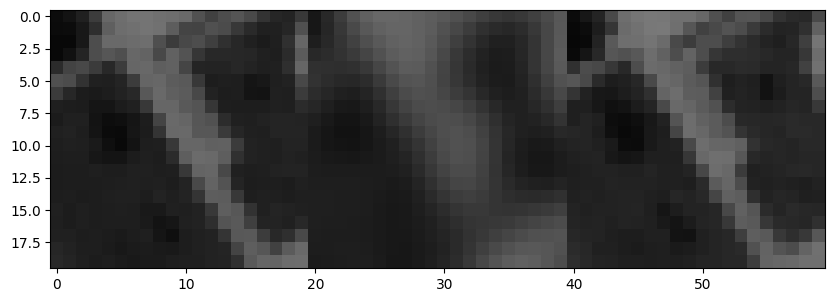

In [2]:
n=1800
i=45
p=np.hstack((hrdata[n,:,:,i], lrdata[n,:,:,i], mrdata[n,:,:,2]))
fig, ax = plt.subplots(figsize=(10, 10))
pyplot.imshow(p, vmin=0, vmax=1, cmap='gray')
pyplot.show()


# Model

In [3]:
num_filter = 32

# -------- Spec & Spat Blocks (using built-in PReLU) --------
def spec(inputs, nf):
    x = layers.Conv2D(nf, 1, padding="same", use_bias=True)(inputs)
    x = layers.PReLU()(x)
    x = layers.Conv2D(nf, 1, padding="same", use_bias=True)(x)
    x = layers.PReLU()(x)
    return inputs + x

def spat(inputs, nf):
    x = layers.Conv2D(nf, 3, padding="same", use_bias=True)(inputs)
    x = layers.PReLU()(x)
    x = layers.Conv2D(nf, 3, padding="same", use_bias=True)(x)
    x = layers.PReLU()(x)
    return inputs + x

# ****************************** MSI Encoder ******************************
msi_input = keras.Input(shape=(hrsize, hrsize, msi_bands,), name="msi_input")
x01 = layers.Conv2D(num_filter, 3, padding="same", use_bias=True)(msi_input)
x01 = layers.PReLU()(x01)

x02 = spec(x01, num_filter)
x02 = spat(x02, num_filter)
x03 = layers.concatenate([x01, x02])

x04 = layers.Conv2D(num_filter, 3, padding="same", use_bias=True)(x03)
x04 = layers.PReLU()(x04)
x05 = spec(x04, num_filter)
x05 = spat(x05, num_filter)
x06 = layers.concatenate([x01, x04, x05])

x07 = layers.Conv2D(num_filter, 5, padding="same", use_bias=True)(x06)
x07 = layers.PReLU()(x07)
x07 = spec(x07, num_filter)
x08 = spat(x07, num_filter)

# ****************************** LR_HSI Encoder ******************************
lr_input = keras.Input(shape=(hrsize, hrsize, hsi_bands), name="lr_input")
x11 = layers.Conv2D(num_filter, 3, padding="same", use_bias=True)(lr_input)
x11 = layers.PReLU()(x11)

x12 = spec(x11, num_filter)
x12 = spat(x12, num_filter)
x13 = layers.concatenate([x11, x12])

x14 = layers.Conv2D(num_filter, 3, padding="same", use_bias=True)(x13)
x14 = layers.PReLU()(x14)
x15 = spec(x14, num_filter)
x15 = spat(x15, num_filter)
x16 = layers.concatenate([x11, x14, x15])

x17 = layers.Conv2D(num_filter, 5, padding="same", use_bias=True)(x16)
x17 = layers.PReLU()(x17)
x17 = spec(x17, num_filter)
x18 = spat(x17, num_filter)

# ********************************* concat ***********************************
x21 = layers.concatenate([x01, x04, x07, x08, x11, x14, x17, x18])

x22 = layers.Conv2D(hsi_bands, 3, padding="same", use_bias=True)(x21)
x22 = layers.PReLU()(x22)

fuse_output = layers.Conv2D(hsi_bands, 3, padding="same", use_bias=True, name="fuse_output")(x22)
fuse_output = layers.PReLU()(fuse_output)

# ******************************** Model ***********************************
model = keras.Model(
    inputs=[msi_input, lr_input],
    outputs=[fuse_output],
)

model.summary()
keras.utils.plot_model(model, "multi_input_and_output_model.png", show_shapes=True)


I0000 00:00:1759239295.812608      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759239295.813353      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ msi_input           │ (None, 20, 20, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lr_input            │ (None, 20, 20,    │          0 │ -                 │
│ (InputLayer)        │ 103)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 20,    │      1,184 │ msi_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 20, 20,    │     29,696 │ lr_input[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu (PReLU)     │ (None, 20, 20,    │     12,800 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_15 (PReLU)  │ (None, 20, 20,    │     12,800 │ conv2d_15[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 20, 20,    │      1,056 │ p_re_lu[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 20, 20,    │      1,056 │ p_re_lu_15[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_1 (PReLU)   │ (None, 20, 20,    │     12,800 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_16 (PReLU)  │ (None, 20, 20,    │     12,800 │ conv2d_16[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 20,    │      1,056 │ p_re_lu_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 20, 20,    │      1,056 │ p_re_lu_16[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_2 (PReLU)   │ (None, 20, 20,    │     12,800 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_17 (PReLU)  │ (None, 20, 20,    │     12,800 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 20,    │          0 │ p_re_lu[0][0],    │
│                     │ 32)               │            │ p_re_lu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 20, 20,    │          0 │ p_re_lu_15[0][0], │
│                     │ 32)               │            │ p_re_lu_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 20,    │      9,248 │ add[0][0]       

 Total params: 1,144,519 (4.37 MB)

 Trainable params: 1,144,519 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [4]:
print(lrdata.shape, mrdata.shape)

(2714, 20, 20, 103) (2714, 20, 20, 4)


In [5]:
# Ensure correct dtype
mrdata = mrdata.astype('float32')
lrdata = lrdata.astype('float32')
hrdata = hrdata.astype('float32')

model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.MeanSquaredError(),
)

model.fit(
    {"msi_input": mrdata, "lr_input": lrdata},
    hrdata,   # ✅ pass directly
    epochs=1000,
    batch_size=64,
)

model.save('/kaggle/working/BASFE_PaviaU_4x_trained.keras')


Epoch 1/1000


I0000 00:00:1759239325.024020      64 service.cc:148] XLA service 0x7aa1c0003530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759239325.025475      64 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759239325.025495      64 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759239327.249263      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/43 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0314

I0000 00:00:1759239334.503849      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 223ms/step - loss: 0.0201
Epoch 2/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0082
Epoch 3/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0059
Epoch 4/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0046
Epoch 5/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0031
Epoch 6/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0014
Epoch 7/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0011
Epoch 8/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 9.6820e-04
Epoch 9/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 8.4359e-04
Epoch 10/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 7.9490e-04
Epoch 11/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 7.2085e-04
Epoch 12/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 6.9896e-04
Epoch 13/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 6.3327e-04
Epoch 14/1000
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 5.8183e-04
Epoch 15/1000
43/43 ━━━━━━

# Reconstruction & Assessment

In [6]:
# ****************************************************************************
# *************          Fusion with lrhsi upsampled         *****************
# ****************************************************************************


import os
from scipy.io import savemat
save_dir = "/kaggle/working/BASFE"
os.makedirs(save_dir, exist_ok=True)


#   **************        Preparing inputs for fusion      *****************
width = int(lrhsi.shape[1] * scale)
height = int(lrhsi.shape[0] * scale)
dim = (width, height)
# resize image
resized = cv.resize(lrhsi, dim, interpolation = cv.INTER_CUBIC)
print('Resized Dimensions : ',resized.shape)
# ****************************************************************************

edge=2                                  # for overlapping patches
strider = hrsize - 2*edge
lrstrider = int(strider/scale)

print('hrmsi', hrmsi.shape, '\nlrhsi', lrhsi.shape, '\nhrhsi', hrhsi.shape)

ii=np.arange(0, hrmsi.shape[0], strider)
jj=np.arange(0, hrmsi.shape[1], strider)
if ii[-1]+hrsize>hrmsi.shape[0]:
  ii[-1]=hrmsi.shape[0]-hrsize
if ii[-2]>=ii[-1]:
  ii[-2]=ii[-1]
  ii=ii[0:-1]
if jj[-1]+hrsize>hrmsi.shape[1]:
  jj[-1]=hrmsi.shape[1]-hrsize
if jj[-2]>=jj[-1]:
  jj[-2]=jj[-1]
  jj=jj[0:-1]

count=0
num_of_data=ii.shape[0]*jj.shape[0]
mrdatainput=np.zeros((num_of_data, hrsize, hrsize,hrmsi.shape[2]))
lrdatainput=np.zeros((num_of_data, hrsize, hrsize, lrhsi.shape[2]))
for i in ii:
  for j in jj:
    mrdatainput[count, :, :, :]=hrmsi[i:i+hrsize, j:j+hrsize, :]
    lrdatainput[count, :, :, :]=resized[i:i+hrsize, j:j+hrsize, :]
    count=count+1


# ****************************************************************************
# **************************      Prediction      ****************************
# ****************************************************************************
iminput=(mrdatainput, lrdatainput)
impred = model.predict(iminput, verbose=0)

# ****************************************************************************
# ************************      Reconstruction      ***************************
# ****************************************************************************
count=0
reconstoutput=np.zeros(hrhsi.shape)
for i in ii:
  for j in jj:
    reconstoutput[i:i+hrsize,j:j+hrsize,:]=impred[count,:,:,:]
    count=count+1
count=0
for i in ii:
  for j in jj:
    reconstoutput[i+edge:i+hrsize-edge,j+edge:j+hrsize-edge,:]=impred[count,edge:-edge,edge:-edge,:]
    count=count+1

mdic = {"reconst_PaviaU": reconstoutput}
savemat(os.path.join(save_dir, "reconst_PaviaU.mat"), mdic)

print("Saved to:", os.path.join(save_dir, "reconst_PaviaU.mat"))


Resized Dimensions :  (608, 336, 103)
hrmsi (608, 336, 4) 
lrhsi (152, 84, 103) 
hrhsi (608, 336, 103)
Saved to: /kaggle/working/BASFE/reconst_PaviaU.mat


In [7]:
# ************************ Assessment *************************************

y = hrhsi[48:176,48:176,:]                 # test region of ground truth
x = reconstoutput[48:176,48:176,:]         # test region of reconstructed output

z=x.shape
n = z[0]*z[1]
L = z[2]

# **************** RMSE ****************
temp = np.sum(np.sum((x-y)*(x-y),axis=0),axis=0)/n
rmse_per_band = np.sqrt(temp)
rmse_total = np.sqrt(np.sum(temp)/L)
print('RMSE=', rmse_total)
print('PSNR=',10*np.log10(1/rmse_total**2),'dB')

# **************** SAM ****************
num = np.sum( x*y,axis=2 )
den = np.sqrt( np.sum(x*x,axis=2)*np.sum(y*y,axis=2) )
tt = num/den
sam = np.mean( np.arccos( num/den ) )
print('SAM=', sam*180/3.14159)

# **************** ERGAS ****************
mean_y = np.sum(np.sum(y,axis=0),axis=0)/n
ergas = 100/scale*np.sqrt(np.sum((rmse_per_band / mean_y)**2)/L)
print('ERGAS=', ergas)

# **************** UIQI ****************
wind_size=32
z0=z[0]-np.remainder(z[0],wind_size)
z1=z[1]-np.remainder(z[1],wind_size)
z2=z[2]
ii=np.arange(0,z0,wind_size)
jj=np.arange(0,z1,wind_size)
n_wind=np.size(ii) * np.size(jj)

count=0
t1=np.zeros((wind_size,wind_size,z2,n_wind))
t2=np.zeros((wind_size,wind_size,z2,n_wind))
for i in ii:
  for j in jj:
    t1[:,:,:,count]=x[i:i+wind_size,j:j+wind_size,:]
    t2[:,:,:,count]=y[i:i+wind_size,j:j+wind_size,:]
    count=count+1

mu_x=np.mean(np.mean(t1,axis=0),axis=0)
mu_y=np.mean(np.mean(t2,axis=0),axis=0)
sig2_x=np.mean(np.mean(t1**2,axis=0),axis=0) - mu_x**2
sig2_y=np.mean(np.mean(t2**2,axis=0),axis=0) - mu_y**2
cov_xy=np.mean(np.mean(t1*t2,axis=0),axis=0)-mu_x*mu_y
t3 = ( 4 * cov_xy * mu_x * mu_y ) / ( (sig2_x + sig2_y)*(mu_x**2 + mu_y**2) )
uiqi = np.mean(t3)
print('UIQI=', uiqi)


# **************** MSSIM ****************
c1=.0001
c2=.0001
ssim = np.zeros((z[2]))
sigma2_x = np.zeros((z[2]))
sigma2_y = np.zeros((z[2]))
sigma_xy = np.zeros((z[2]))
mean_x = np.sum(np.sum(x,axis=0),axis=0)/n
mean_y = np.sum(np.sum(y,axis=0),axis=0)/n
for i in range(z[2]):
  sigma2_x[i]=np.mean(x[:,:,i]**2)-mean_x[i]**2
  sigma2_y[i]=np.mean(y[:,:,i]**2)-mean_y[i]**2
  sigma_xy[i]=np.mean(x[:,:,i]*y[:,:,i])-mean_x[i]*mean_y[i]
  ssim[i] = ((2*mean_x[i]*mean_y[i]+c1)*(2*sigma_xy[i]+c2))/((mean_x[i]**2+mean_y[i]**2+c1)*(sigma2_x[i]+sigma2_y[i]+c2))
print('MSSIM=', np.mean(ssim))


# ****************  CC  ****************
cc = np.zeros((z[2]))
for i in range(z[2]):
  cc[i]= np.sum((x[:,:,i]-mean_x[i])*(y[:,:,i]-mean_y[i])) / np.sqrt(np.sum((x[:,:,i]-mean_x[i])**2)*np.sum((y[:,:,i]-mean_y[i])**2))
print('CC = ', np.mean(cc))



RMSE= 0.007194225438695322
PSNR= 42.86031914450817 dB
SAM= 1.8977494170968308
ERGAS= 1.3024065000135652
UIQI= 0.9873555681661141
MSSIM= 0.9964116791497979
CC =  0.9964362299806759
